First 5 records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data Types:
Pregnancies                   int64
Glucose                       int64


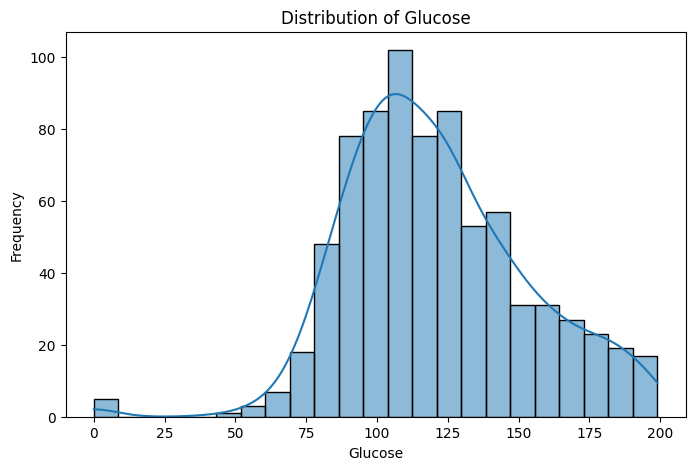

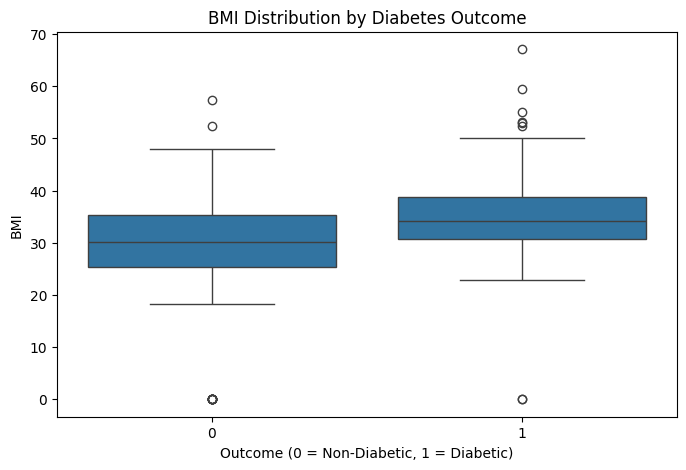

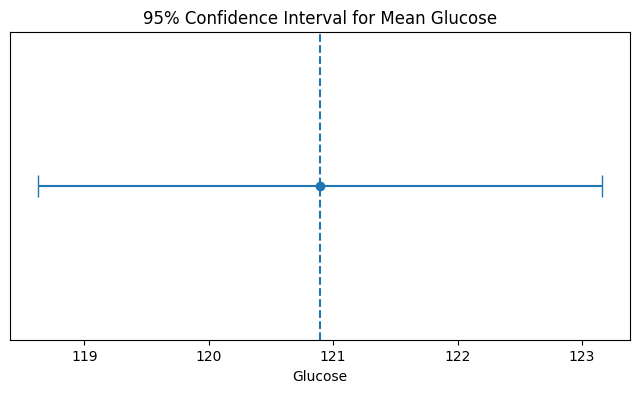


FINAL RESULTS
Mean Glucose: 120.89
95% CI for Mean Glucose: (118.63, 123.16)
One-Sample T-Test P-value: 0.438372
Two-Sample T-Test P-value: 0.000000
Chi-Square Test P-value: 0.000000
Sample Proportion of Diabetic Patients: 0.3490


In [ ]:
# ============================================
# EXPERIMENT 4
# Statistical Inference, Estimation,
# and Hypothesis Testing
# ============================================

# Import required libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("/content/sample_data/diabetes.csv")

print("First 5 records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# ============================================
# 2. BASIC DATA INFORMATION
# ============================================

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================
# 3. POINT ESTIMATION
# ============================================

# Sample mean of Glucose
glucose_mean = df["Glucose"].mean()

# Sample standard deviation
glucose_std = df["Glucose"].std()

# Sample size
n = df["Glucose"].count()

# Sample proportion of diabetic patients
diabetic_count = df["Outcome"].sum()
sample_proportion = diabetic_count / n

print("\n--- POINT ESTIMATION ---")

print("Sample Mean of Glucose:", glucose_mean)
print("Sample Standard Deviation of Glucose:", glucose_std)
print("Sample Size:", n)

print("Number of Diabetic Patients:", diabetic_count)
print("Sample Proportion of Diabetic Patients:",
      sample_proportion)

# ============================================
# 4. 95% CONFIDENCE INTERVAL FOR MEAN GLUCOSE
# ============================================

confidence = 0.95
alpha = 1 - confidence

t_critical = stats.t.ppf(
    1 - alpha / 2,
    df=n - 1
)

margin_of_error = t_critical * glucose_std / np.sqrt(n)

lower_bound = glucose_mean - margin_of_error
upper_bound = glucose_mean + margin_of_error

print("\n--- 95% CONFIDENCE INTERVAL ---")

print("Mean Glucose:", glucose_mean)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print(
    f"95% Confidence Interval for Mean Glucose: "
    f"({lower_bound:.2f}, {upper_bound:.2f})"
)

# ============================================
# 5. ONE-SAMPLE T-TEST
# ============================================

# H0: Mean glucose = 120
# H1: Mean glucose != 120

reference_value = 120

t_statistic, p_value = stats.ttest_1samp(
    df["Glucose"],
    reference_value
)

print("\n--- ONE-SAMPLE T-TEST ---")

print("Null Hypothesis (H0): Mean Glucose = 120")
print("Alternative Hypothesis (H1): Mean Glucose != 120")

print("Reference Value:", reference_value)
print("T-statistic:", t_statistic)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject H0")
    print("Conclusion: Mean glucose is significantly different from 120.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: There is insufficient evidence that mean glucose differs from 120.")

# ============================================
# 6. TWO-SAMPLE T-TEST
# ============================================

# Separate BMI according to Outcome

diabetic_bmi = df[df["Outcome"] == 1]["BMI"]
non_diabetic_bmi = df[df["Outcome"] == 0]["BMI"]

# H0: Mean BMI of both groups is equal
# H1: Mean BMI of both groups is different

t_stat, p_val = stats.ttest_ind(
    diabetic_bmi,
    non_diabetic_bmi,
    equal_var=False
)

print("\n--- TWO-SAMPLE T-TEST ---")

print("Mean BMI - Diabetic:", diabetic_bmi.mean())
print("Mean BMI - Non-Diabetic:", non_diabetic_bmi.mean())

print("Null Hypothesis (H0): Mean BMI of both groups is equal")
print("Alternative Hypothesis (H1): Mean BMI of both groups is different")

print("T-statistic:", t_stat)
print("P-value:", p_val)

if p_val < alpha:
    print("Decision: Reject H0")
    print("Conclusion: BMI differs significantly between the two groups.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: There is insufficient evidence of a significant BMI difference.")

# ============================================
# 7. CHI-SQUARE TEST
# ============================================

# Create a categorical variable for Glucose
# Low/Normal: Glucose < 140
# High: Glucose >= 140

df["Glucose_Category"] = np.where(
    df["Glucose"] >= 140,
    "High",
    "Low/Normal"
)

# Contingency table
contingency_table = pd.crosstab(
    df["Glucose_Category"],
    df["Outcome"]
)

print("\n--- CONTINGENCY TABLE ---")
print(contingency_table)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("\n--- CHI-SQUARE TEST ---")

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

if p < alpha:
    print("Decision: Reject H0")
    print("Conclusion: Glucose category and diabetes outcome are associated.")
else:
    print("Decision: Fail to Reject H0")
    print("Conclusion: There is insufficient evidence of an association.")

# ============================================
# 8. VISUALIZATION OF GLUCOSE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Glucose"],
    kde=True
)

plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 9. BOXPLOT OF BMI BY OUTCOME
# ============================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Outcome",
    y="BMI",
    data=df
)

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("BMI")
plt.show()

# ============================================
# 10. VISUALIZE CONFIDENCE INTERVAL
# ============================================

plt.figure(figsize=(8, 4))

plt.errorbar(
    x=glucose_mean,
    y=0,
    xerr=margin_of_error,
    fmt='o',
    capsize=8
)

plt.axvline(
    glucose_mean,
    linestyle='--'
)

plt.title("95% Confidence Interval for Mean Glucose")
plt.xlabel("Glucose")
plt.yticks([])
plt.show()

# ============================================
# 11. FINAL SUMMARY
# ============================================

print("\n============================================")
print("FINAL RESULTS")
print("============================================")

print(f"Mean Glucose: {glucose_mean:.2f}")

print(
    f"95% CI for Mean Glucose: "
    f"({lower_bound:.2f}, {upper_bound:.2f})"
)

print(f"One-Sample T-Test P-value: {p_value:.6f}")

print(f"Two-Sample T-Test P-value: {p_val:.6f}")

print(f"Chi-Square Test P-value: {p:.6f}")

print(f"Sample Proportion of Diabetic Patients: "
      f"{sample_proportion:.4f}")

print("============================================")